<a href="https://colab.research.google.com/github/mayajdias/A02-eda-and-visualization/blob/main/notebook_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

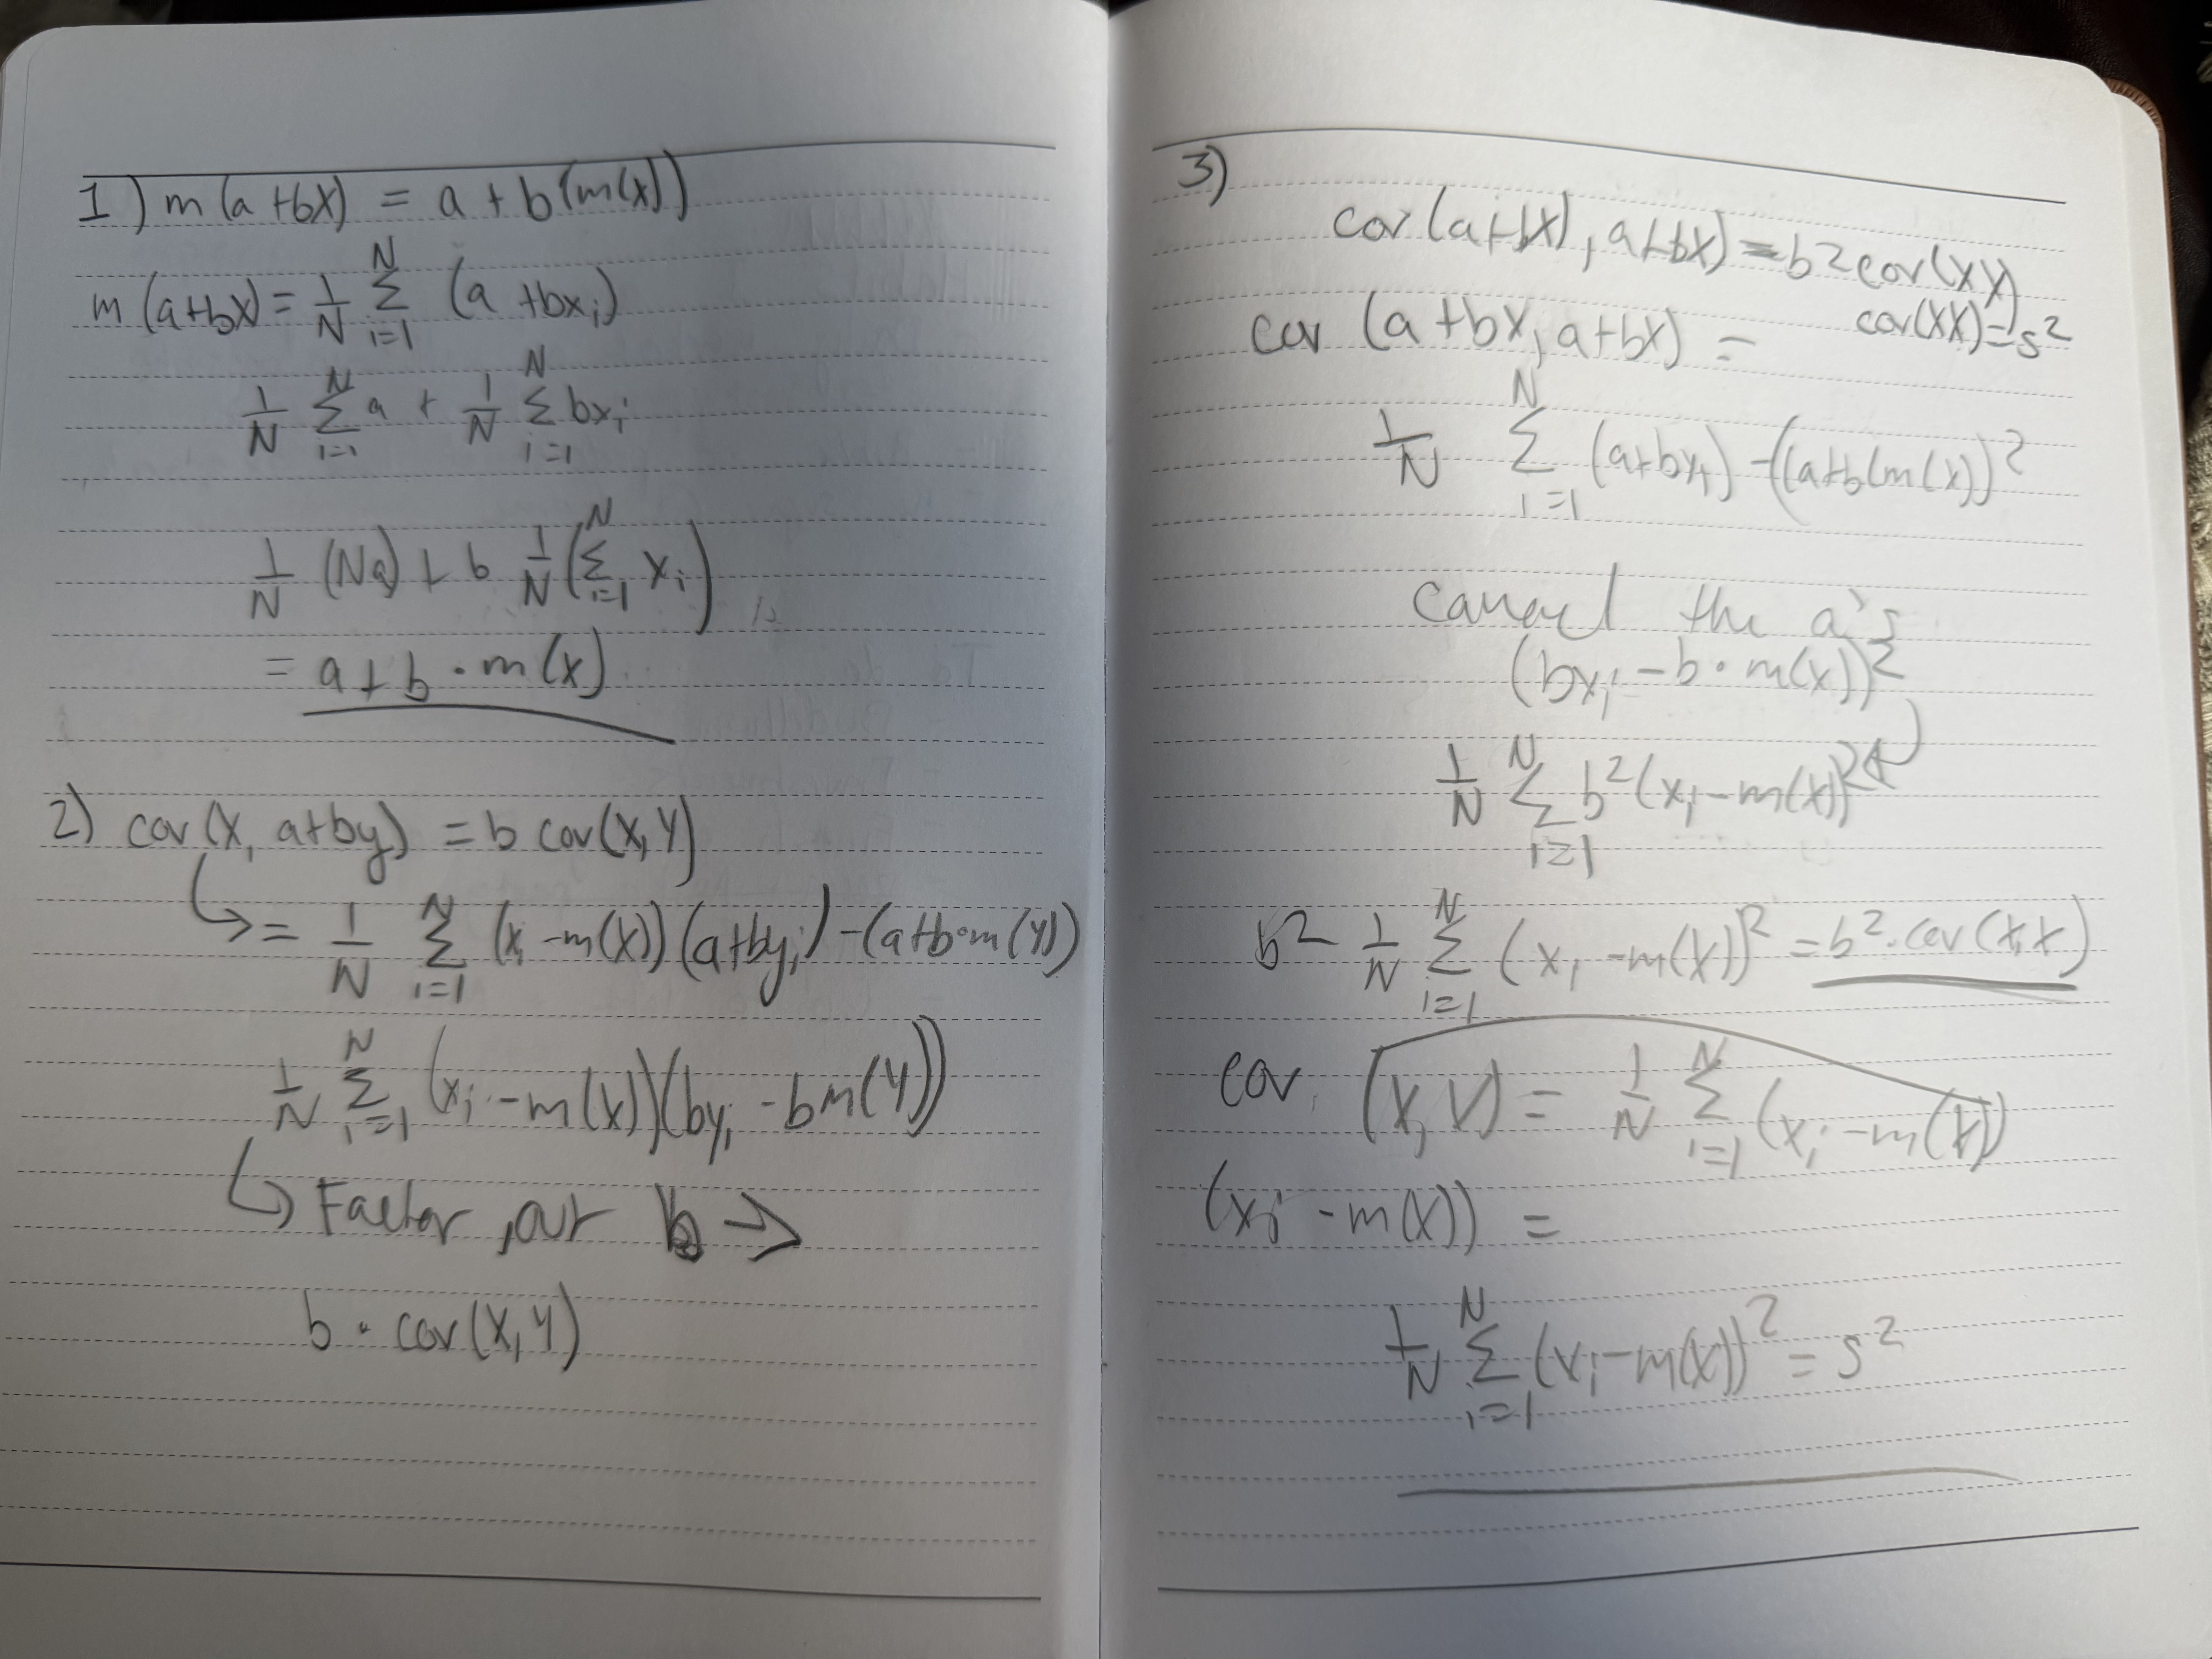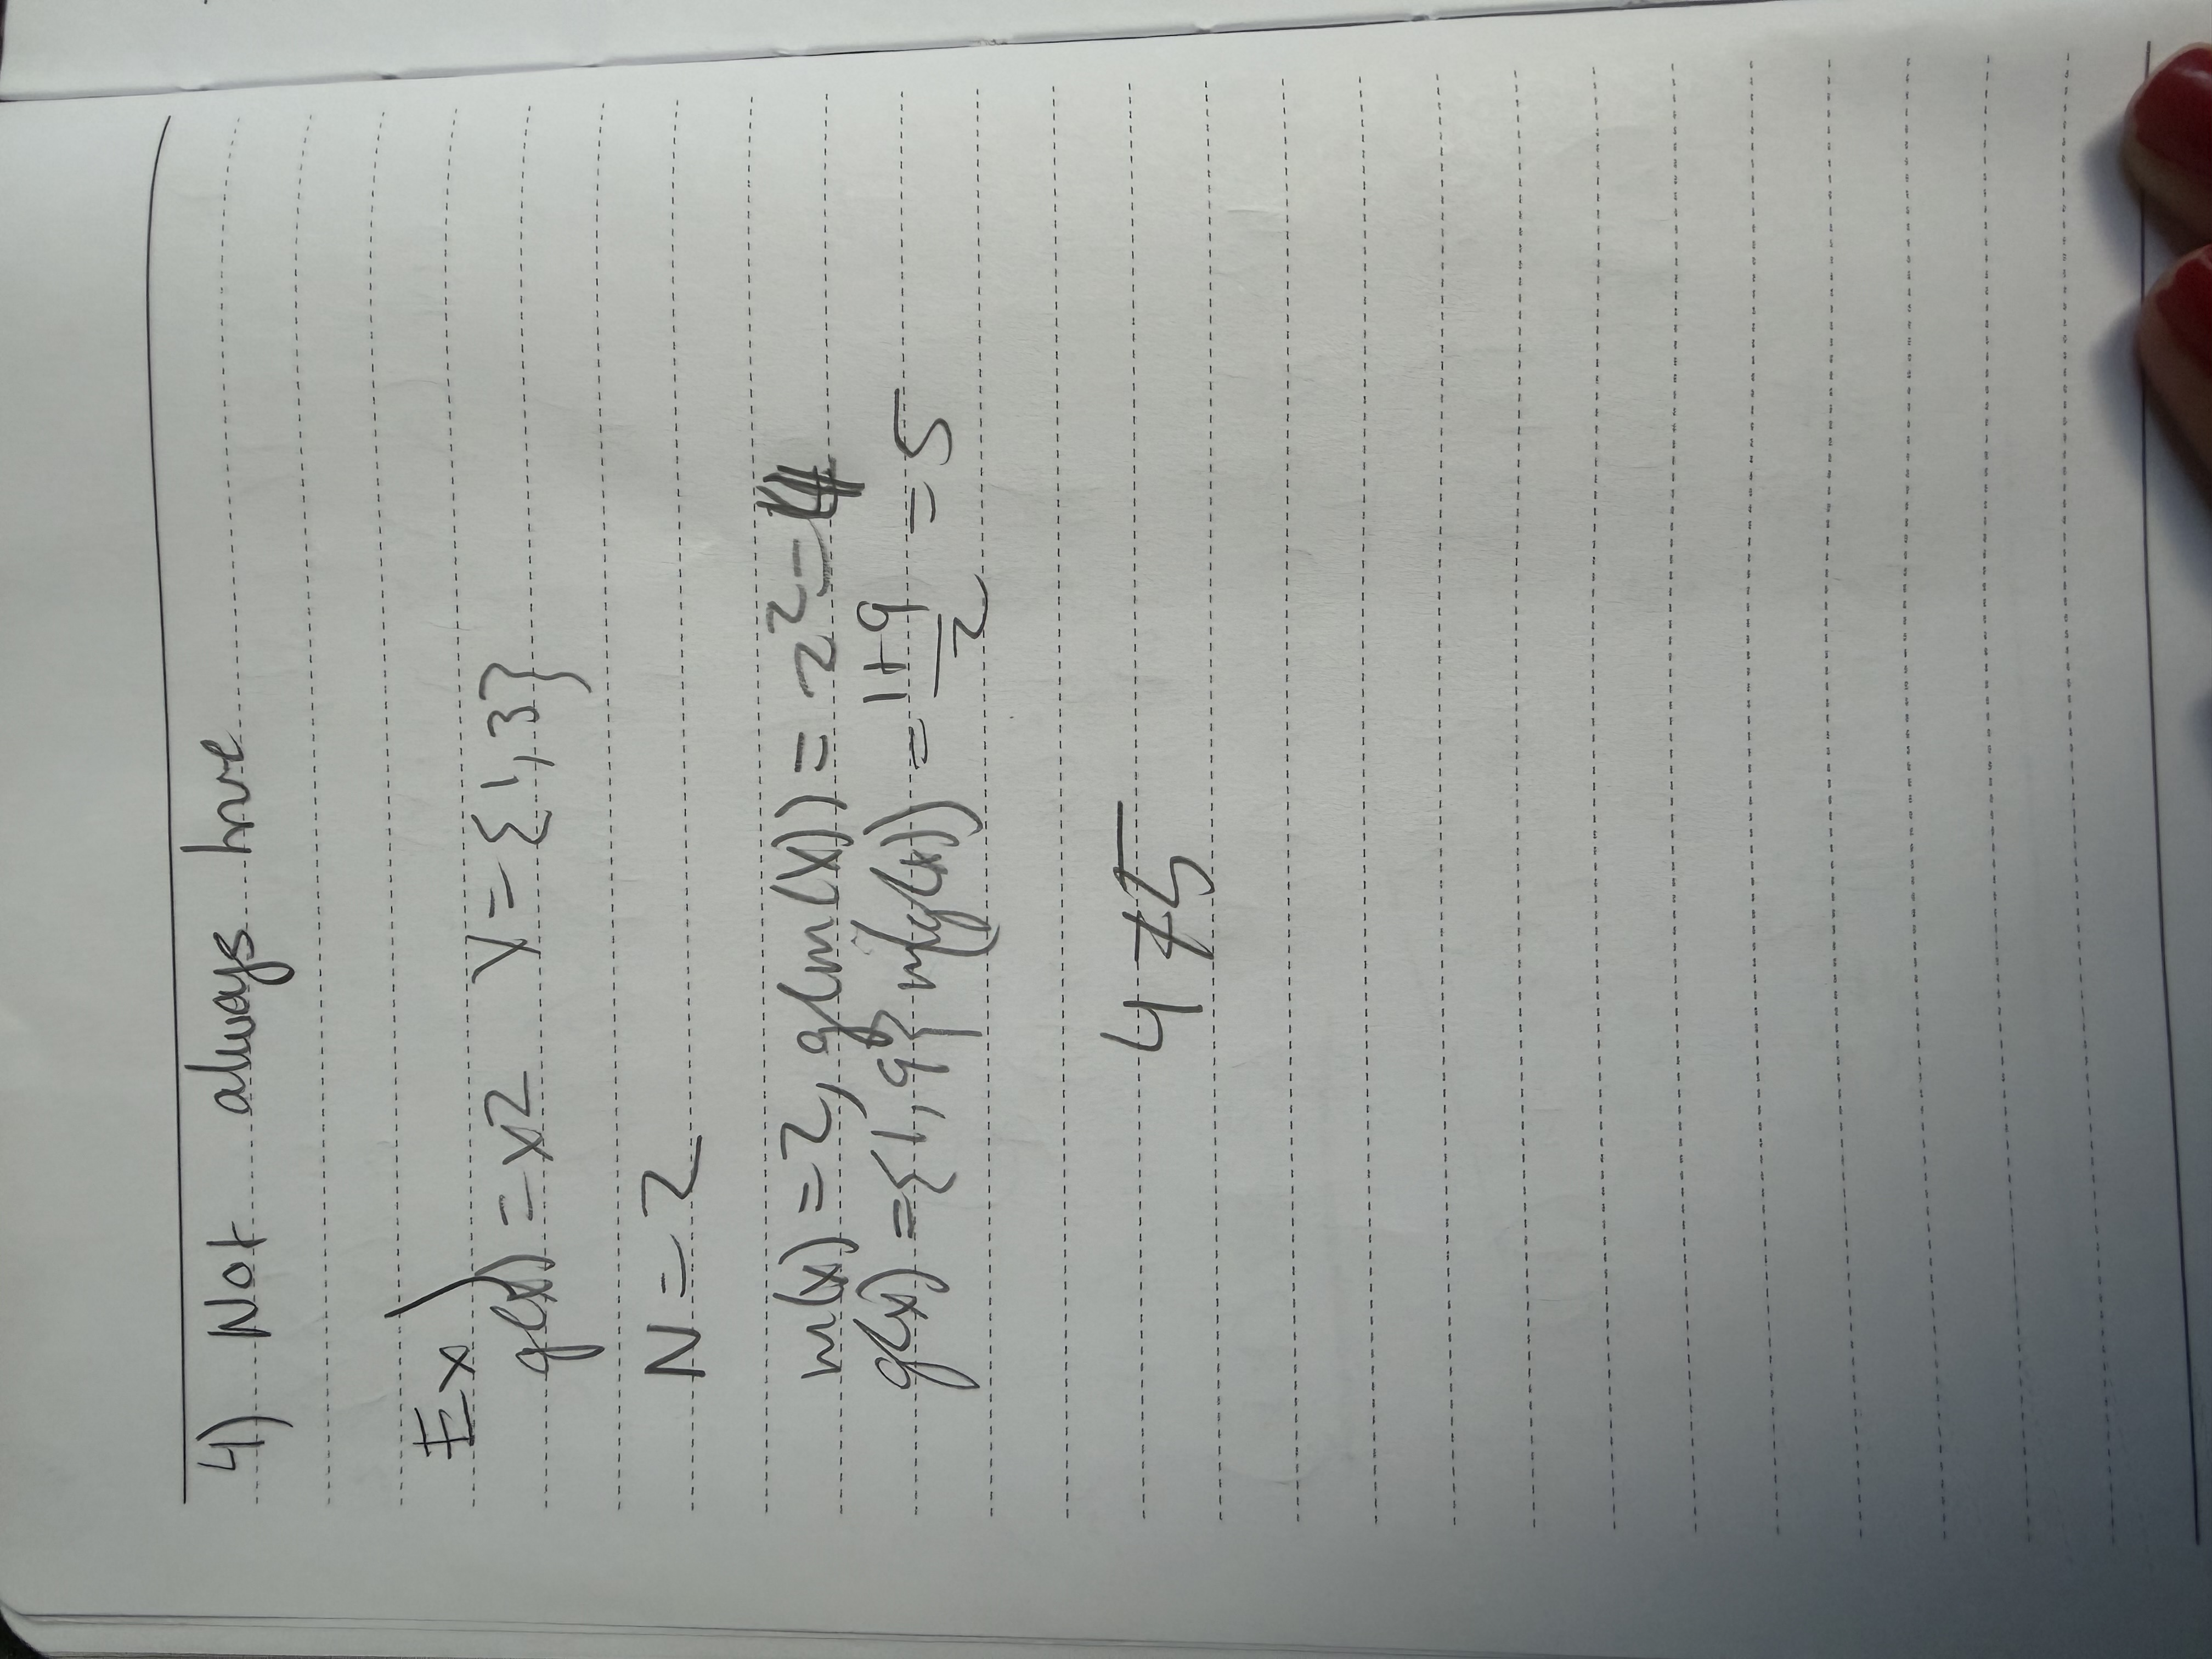

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [1]:
# Your Phase 1 solution to the problem goes here.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the data in
df = pd.read_csv("ForeignGifts_edu.csv")
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


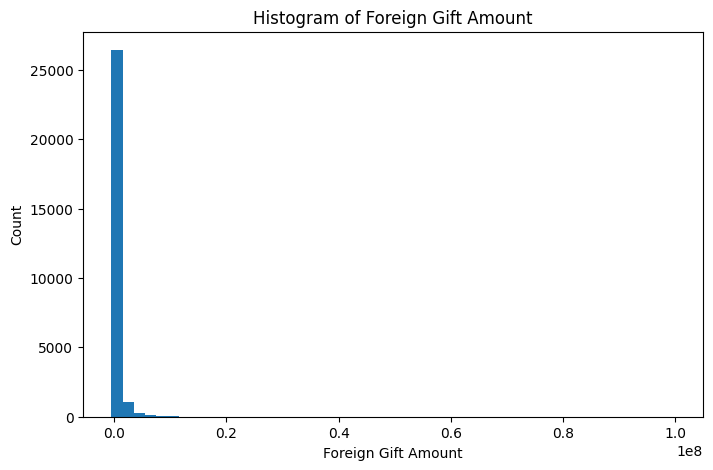

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


In [3]:
# 2.histogram for the Foreign Gift Amount column

plt.figure(figsize=(8,5))
plt.hist(df['Foreign Gift Amount'], bins=50)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Count')
plt.title('Histogram of Foreign Gift Amount')
plt.show()

# this will print out some basic stats for us
print(df['Foreign Gift Amount'].describe())

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


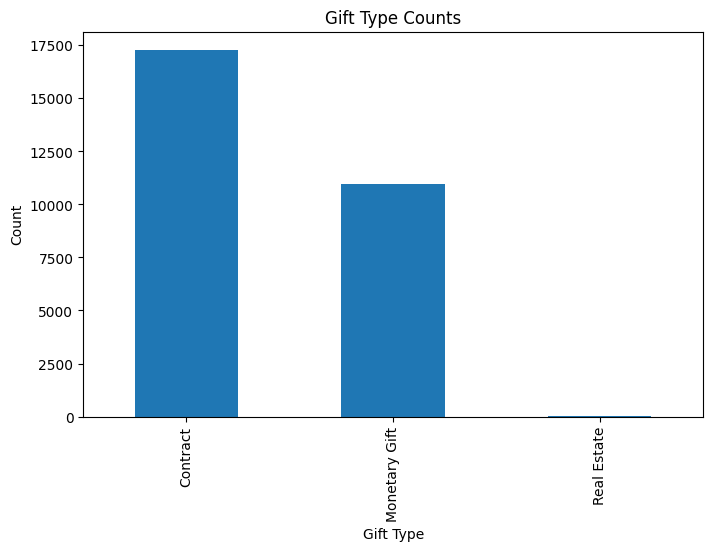

In [4]:
# 3. now lets check the Gift Type column

gift_counts = df['Gift Type'].value_counts()
print(gift_counts)

# same thing but as proportions/percentages instead of raw counts
gift_props = df['Gift Type'].value_counts(normalize=True)
print(gift_props)

# bar chart since Gift Type is not numbers, its categories
gift_counts.plot(kind='bar', figsize=(8,5))
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.title('Gift Type Counts')
plt.show()

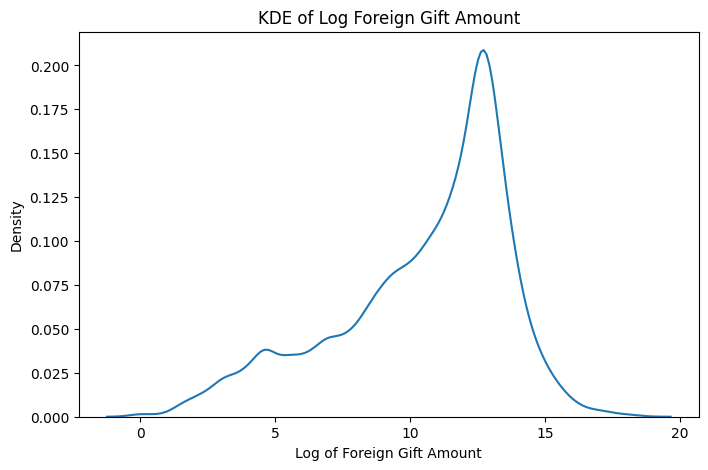

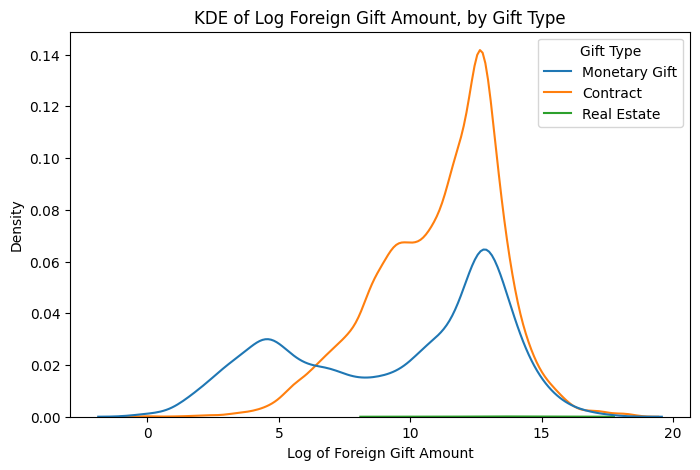

In [5]:
# 4. kernel density plots of the log of Foreign Gift Amount

# gotta get rid of the negative/zero values first or log will break
df_pos = df[df['Foreign Gift Amount'] > 0].copy()
df_pos['log_amount'] = np.log(df_pos['Foreign Gift Amount'])

# first the overall kde plot
plt.figure(figsize=(8,5))
sns.kdeplot(df_pos['log_amount'])
plt.xlabel('Log of Foreign Gift Amount')
plt.title('KDE of Log Foreign Gift Amount')
plt.show()

# now same thing but split up by gift type so we can compare them
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_pos, x='log_amount', hue='Gift Type')
plt.xlabel('Log of Foreign Gift Amount')
plt.title('KDE of Log Foreign Gift Amount, by Gift Type')
plt.show()

In [6]:
# 5. top 15 countries, by how many gifts and by how much money

# by number of gifts (using count)
top_countries_count = df.groupby('Country of Giftor').count()['Foreign Gift Amount'].sort_values(ascending=False).head(15)
print("top 15 countries by number of gifts:")
print(top_countries_count)

# by total dollar amount (using sum)
top_countries_amount = df.groupby('Country of Giftor').sum(numeric_only=True)['Foreign Gift Amount'].sort_values(ascending=False).head(15)
print("top 15 countries by total amount given:")
print(top_countries_amount)

top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
top 15 countries by total amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                4011576

In [7]:

# 6. which giftors gives the most money overall

top_giftors = df.groupby('Giftor Name').sum(numeric_only=True)['Foreign Gift Amount'].sort_values(ascending=False).head(15)
print(top_giftors)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

Review my Phase 1 solution for this exploratory data analysis assignment. Identify any errors, missing interpretations, or ways to make the code more accurate while keeping it simple and close to my original coding style. Give me a concise numbered list of proposed changes.

For each proposed change, explain whether it is necessary for answering the assignment questions. I want to keep the solution simple, so point out suggestions that are optional or could make the code unnecessarily complicated.

### *AI-proposed changes


1. Use .groupby().size() instead of counting Foreign Gift Amount when finding the countries with the most gifts, because .count() can exclude rows where the gift amount is missing.
2. Add numerical descriptive statistics and skewness alongside the histogram of Foreign Gift Amount so the description of the variable is supported by the data.
3. Replace the original histogram with a logarithmic x-axis to make the highly skewed gift amounts easier to visualize.
4. Present the Gift Type counts and proportions together in one table and express the proportions as percentages.
5. Use np.log1p() instead of np.log() so observations with a gift amount of zero can remain in the KDE analysis.
6. State how many observations are removed before taking the natural log, since zero and negative values cannot be logged using np.log().
7. Format the country and giftor totals as dollar amounts so the rankings are easier to interpret.
8. Replace the KDE plots with boxplots because boxplots make it easier to compare the different gift types.

### *Evaluation of AI suggestions



| Change                                                                                                | Decision | Reason and verification                                                                                                                                                                                        |
| ----------------------------------------------------------------------------------------------------- | -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. Use `.groupby().size()` instead of `.count()` when finding the countries with the most gifts.      | Accept   | `.size()` counts all gift records in each country group, while `.count()` only counts non-missing values in a selected column. Since the question asks for the number of gifts, `.size()` is more appropriate. |
| 2. Add descriptive statistics and skewness for `Foreign Gift Amount`.                                 | Accept   | The question asks me to describe the distribution. Summary statistics and skewness provide numerical support for what is shown in the histogram.                                                               |
| 3. Change the histogram to use a logarithmic x-axis.                                                  | Reject   | The assignment asks for a histogram of the original `Foreign Gift Amount`. The assignment separately asks for an analysis using the log of gift amount, so I kept the original histogram.                      |
| 4. Combine the `Gift Type` counts and proportions into one table and show proportions as percentages. | Accept   | This makes the results easier to read and directly answers the question about both the number and proportion of observations in each gift type.                                                                |
| 5. Use `np.log1p()` instead of `np.log()` for the gift amounts.                                       | Reject   | `np.log1p()` calculates the log of \(1+x\), which is different from taking the natural log of the gift amount. Since the assignment asks for the log of `Foreign Gift Amount`, I kept `np.log()`.              |
| 6. Show how many observations are removed before taking the log.                                      | Accept   | Zero or negative values cannot be used with `np.log()`, so showing how many observations are excluded makes the filtering step more transparent.                                                               |
| 7. Format the country and giftor totals as dollar amounts.                                            | Accept   | This does not change the calculations, but it makes the results easier to read and interpret.                                                                                                                  |
| 8. Replace the KDE plots with boxplots.                                                               | Reject   | The assignment specifically asks for kernel density plots, so replacing them with boxplots would not directly answer the question.                                                                             |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [8]:
# Your Phase 2 solution to the problem goes here.


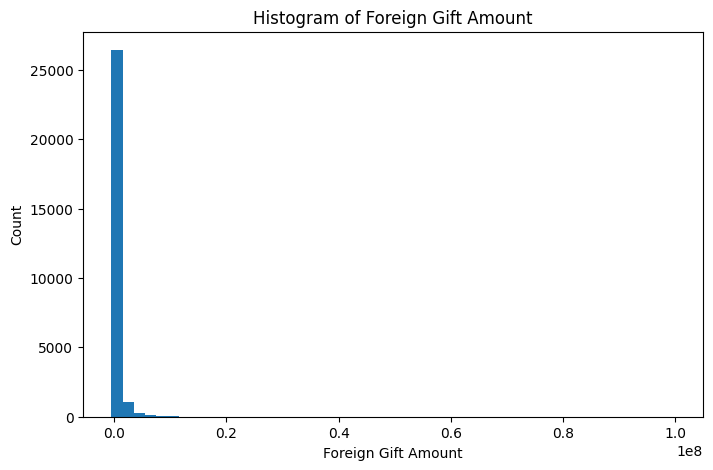

Foreign Gift Amount statistics:
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
Skewness: 18.44
The distribution is strongly right-skewed. Most gifts are smaller amounts, while a smaller number of very large gifts create a long right tail.

Gift Type counts and proportions:
               Count  Percent
Gift Type                    
Contract       17274    61.21
Monetary Gift  10936    38.75
Real Estate       11     0.04


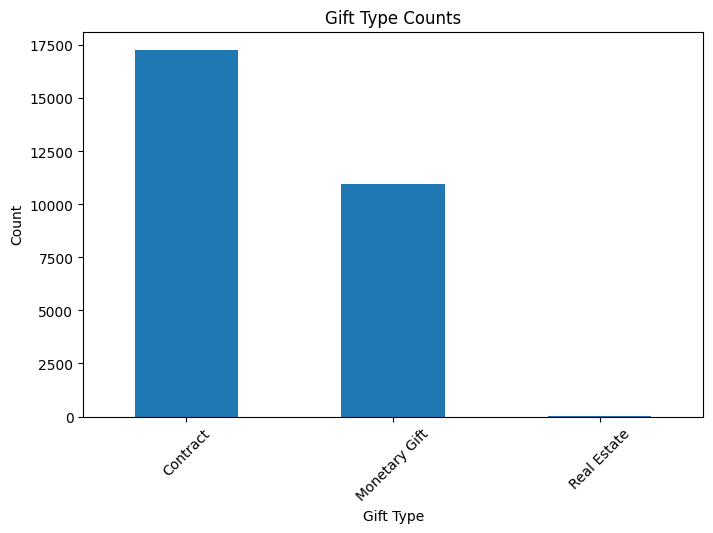


Observations excluded from log analysis: 24


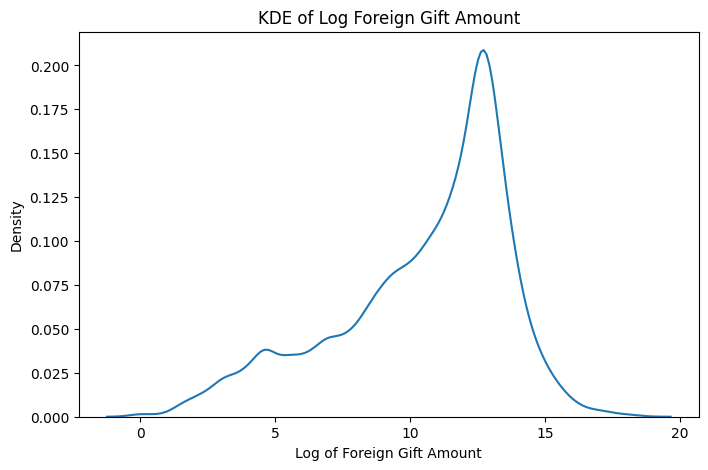

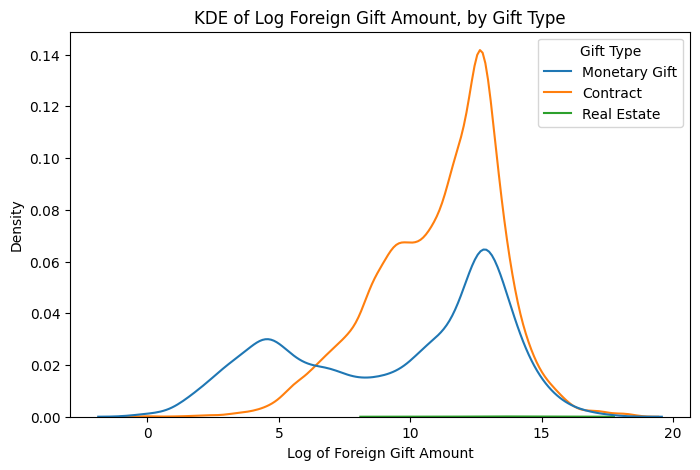


Log gift amount by Gift Type:
               count   mean  median
Gift Type                          
Contract       17250  11.12   11.61
Monetary Gift  10936   9.55   10.82
Real Estate       11  13.48   13.41
The log transformation makes the distributions easier to compare by reducing the effect of extremely large gifts. Differences in the locations and shapes of the curves show that some gift types tend to have larger gift amounts than others.

Top 15 countries by number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 countries by total amount given:
QATAR: $2,706,240,869.00
ENGLAND: $1,464,906,771.00
CHINA: $1,237,952,112.00
SA

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. load the data
df = pd.read_csv("ForeignGifts_edu.csv")
df.head()


# 2. histogram for Foreign Gift Amount

amount = df['Foreign Gift Amount'].dropna()

plt.figure(figsize=(8,5))
plt.hist(amount, bins=50)
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Count')
plt.title('Histogram of Foreign Gift Amount')
plt.show()

# basic statistics and skewness to help describe the distribution
print("Foreign Gift Amount statistics:")
print(amount.describe())
print("Skewness:", round(amount.skew(), 2))

if amount.skew() > 1:
    print("The distribution is strongly right-skewed. Most gifts are smaller amounts, while a smaller number of very large gifts create a long right tail.")
elif amount.skew() > 0:
    print("The distribution is somewhat right-skewed.")
else:
    print("The distribution is relatively symmetric or left-skewed.")


# 3. Gift Type counts and proportions

gift_counts = df['Gift Type'].value_counts()
gift_props = df['Gift Type'].value_counts(normalize=True) * 100

gift_type_table = pd.DataFrame({
    'Count': gift_counts,
    'Percent': gift_props
})

print("\nGift Type counts and proportions:")
print(gift_type_table.round(2))

gift_counts.plot(kind='bar', figsize=(8,5))
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.title('Gift Type Counts')
plt.xticks(rotation=45)
plt.show()


# 4. kernel density plots of the log of Foreign Gift Amount

# remove zero and negative values because np.log() requires positive values
df_pos = df[df['Foreign Gift Amount'] > 0].copy()

removed = len(df) - len(df_pos)
print("\nObservations excluded from log analysis:", removed)

df_pos['log_amount'] = np.log(df_pos['Foreign Gift Amount'])

# overall KDE
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_pos, x='log_amount')
plt.xlabel('Log of Foreign Gift Amount')
plt.title('KDE of Log Foreign Gift Amount')
plt.show()

# KDE conditional on Gift Type
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_pos, x='log_amount', hue='Gift Type')
plt.xlabel('Log of Foreign Gift Amount')
plt.title('KDE of Log Foreign Gift Amount, by Gift Type')
plt.show()

# summary statistics to help compare gift types
print("\nLog gift amount by Gift Type:")
print(
    df_pos.groupby('Gift Type')['log_amount']
    .agg(['count', 'mean', 'median'])
    .round(2)
)

print("The log transformation makes the distributions easier to compare by reducing the effect of extremely large gifts. Differences in the locations and shapes of the curves show that some gift types tend to have larger gift amounts than others.")


# 5. top 15 countries by number of gifts and total amount given

# use size() because we want the number of gifts/rows
top_countries_count = (
    df.groupby('Country of Giftor')
      .size()
      .sort_values(ascending=False)
      .head(15)
)

print("\nTop 15 countries by number of gifts:")
print(top_countries_count)


# top 15 countries by total dollar amount
top_countries_amount = (
    df.groupby('Country of Giftor')['Foreign Gift Amount']
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

print("\nTop 15 countries by total amount given:")
for country, amount in top_countries_amount.items():
    print(f"{country}: ${amount:,.2f}")


# 6. giftors that provide the most money overall

top_giftors = (
    df.groupby('Giftor Name')['Foreign Gift Amount']
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

print("\nTop giftors by total amount:")
for giftor, amount in top_giftors.items():
    print(f"{giftor}: ${amount:,.2f}")

### *Reflection on AI assistance
In your own words without generative AI.

 Using AI for Phase 2 helped me notice a few places where my original solution could be made more precise without changing the overall approach. One of the most useful suggestions was changing the country gift count from `.count()` to `.size()`. This better matched the question because I wanted to count the number of gift records rather than only non-missing values in one column. I also accepted suggestions to add skewness and descriptive statistics for the gift amount distribution, show Gift Type proportions as percentages, and report how many observations were excluded before taking the natural log.

I did not accept every suggestion. For example, I rejected changing the original histogram to a logarithmic scale because the assignment asks for a histogram of the original gift amount and then separately asks for an analysis of the logged values. I also rejected using `np.log1p()` because that would calculate the log of one plus the gift amount rather than the natural log of the gift amount itself. I kept the KDE plots instead of replacing them with boxplots because KDE plots were specifically requested.

I verified the changes by comparing them directly with the wording of each question and checking that the revised code still produced all of the required outputs. This process showed me that AI suggestions can be useful, but they still need to be checked carefully against the actual assignment instructions.
